# Cell Type classification

This notebook focusses on cell type classification using the cell embeddings produced with scRepresenter by following the Training Model notebook. We are using Pbmc3k dataset from Scanpy and the corresponding cell type labels.

In [1]:
# imports
import os
import pandas as pa
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
if os.path.basename(os.getcwd()) == 'scripts':
    os.chdir('..')

Start out by reading the embedding object produced by scRepresenter. This AnnData object contains the original processed Pbmc3k counts (see the Preprocessing notebook) as well as the embeddings of the scNET and scGPT models, and the averaged and concatenated hybrid embeddings of both. These embeddings will be used in a classification task to test the benefit of using scRepresenter.

In [2]:
obj = sc.read("./output/pbmc3k/scRepresenter/Embs.h5ad")
obj

AnnData object with n_obs × n_vars = 1056 × 2000
    obs: 'celltype', 'n_genes'
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_combined_avg', 'X_combined_conc', 'X_scgpt', 'X_scnet'

## Create PCA embeddings

Before any classification, the standard PCA of the expression values will serve as the "baseline" for every other type of embeddings.

In [3]:
sc.pp.pca(obj, n_comps=50)
obj

AnnData object with n_obs × n_vars = 1056 × 2000
    obs: 'celltype', 'n_genes'
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_combined_avg', 'X_combined_conc', 'X_scgpt', 'X_scnet', 'X_pca'
    varm: 'PCs'

# Classification architecture

A standard transformer architecture is used as the cell type classifier.

In [4]:
class Classifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(Classifier, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

A standard 5-fold cross validation training loop is also used. It is important to save the predictions so we can add them to the AnnData object for later analysis.

In [5]:
def test_embeddings(obj, epochs, name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    num_folds = 5
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    X = obj.obsm[name]
    y = obj.obs['celltype']
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_losses = []

    all_y_true = []
    all_y_pred = []
    all_test_indices = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        all_test_indices.extend(test_idx)

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)
        y_test_tensor = torch.tensor(y_test, dtype=torch.long)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True, drop_last=False)

        # Initialize model
        input_size = X_train.shape[1]
        num_classes = len(np.unique(y))
        model = Classifier(input_size, num_classes).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Train the model
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            correct_predictions = 0
            total_predictions = 0
            
            for batch_X, batch_y in train_loader:
                
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                _, predicted_labels = torch.max(outputs, 1)
                correct_predictions += (predicted_labels == batch_y).sum().item()
                total_predictions += batch_y.size(0)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
            
            accuracy = correct_predictions / total_predictions

            print(f"Epoch {epoch+1}/{epochs}, Training loss: {total_loss/len(train_loader):.4f}, Training accuracy: {accuracy:.4f}")


        model.eval()
        with torch.inference_mode():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            
            outputs = model(X_test_tensor)
            test_loss = criterion(outputs, y_test_tensor)

            _, predicted = torch.max(outputs, 1)
            y_true = y_test_tensor.cpu().numpy()
            y_pred = predicted.cpu().numpy()

            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, average="macro", zero_division=1)
            recall = recall_score(y_true, y_pred, average="macro")
            f1 = f1_score(y_true, y_pred, average="macro")
            
            print(f"Fold {fold+1}: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1-Score={f1:.4f}")

            fold_losses.append(test_loss.item())
            fold_accuracies.append(accuracy)
            fold_precisions.append(precision)
            fold_recalls.append(recall)
            fold_f1s.append(f1)

            all_y_true.extend(y_true)
            all_y_pred.extend(y_pred)

    print("\nFinal Cross-Validation Results:")
    print(f"Mean Loss: {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}")
    print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
    print(f"Mean Precision: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
    print(f"Mean Recall: {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
    print(f"Mean F1-Score: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")

    true_labels_decoded = label_encoder.inverse_transform(np.array(all_y_true))
    pred_labels_decoded = label_encoder.inverse_transform(np.array(all_y_pred))

    obj.obs[f"{name} prediction"] = None
    obj.obs.loc[obj.obs_names[all_test_indices], f"{name} prediction"] = pred_labels_decoded

    del model, optimizer, criterion
    torch.cuda.empty_cache()

# Classification and results

We can move on to the actual classification process, one for each of the embeddings. For an in-depth analysis of each see the Embedding and Prediction Analysis notebook. 

In [6]:
#scNET
test_embeddings(obj, 10, 'X_pca')

Using device: cuda
Epoch 1/10, Training loss: 1.9867, Training accuracy: 0.2002
Epoch 2/10, Training loss: 1.5656, Training accuracy: 0.5912
Epoch 3/10, Training loss: 1.2024, Training accuracy: 0.7796
Epoch 4/10, Training loss: 0.8430, Training accuracy: 0.8803
Epoch 5/10, Training loss: 0.6070, Training accuracy: 0.9171
Epoch 6/10, Training loss: 0.4590, Training accuracy: 0.9336
Epoch 7/10, Training loss: 0.3982, Training accuracy: 0.9360
Epoch 8/10, Training loss: 0.2926, Training accuracy: 0.9502
Epoch 9/10, Training loss: 0.2612, Training accuracy: 0.9538
Epoch 10/10, Training loss: 0.2375, Training accuracy: 0.9562
Fold 1: Accuracy=0.9151, Precision=0.9210, Recall=0.7272, F1-Score=0.7390
Epoch 1/10, Training loss: 1.9580, Training accuracy: 0.2911
Epoch 2/10, Training loss: 1.5256, Training accuracy: 0.6379
Epoch 3/10, Training loss: 1.1611, Training accuracy: 0.8225
Epoch 4/10, Training loss: 0.8216, Training accuracy: 0.9053
Epoch 5/10, Training loss: 0.5789, Training accuracy

In [7]:
#scNET
test_embeddings(obj, 15, 'X_scnet')

Using device: cuda
Epoch 1/15, Training loss: 1.4748, Training accuracy: 0.7014
Epoch 2/15, Training loss: 0.9838, Training accuracy: 0.8945
Epoch 3/15, Training loss: 0.7357, Training accuracy: 0.9100
Epoch 4/15, Training loss: 0.5892, Training accuracy: 0.8981
Epoch 5/15, Training loss: 0.4706, Training accuracy: 0.9159
Epoch 6/15, Training loss: 0.4298, Training accuracy: 0.9052
Epoch 7/15, Training loss: 0.3910, Training accuracy: 0.9254
Epoch 8/15, Training loss: 0.3600, Training accuracy: 0.9111
Epoch 9/15, Training loss: 0.3332, Training accuracy: 0.9135
Epoch 10/15, Training loss: 0.2997, Training accuracy: 0.9277
Epoch 11/15, Training loss: 0.2954, Training accuracy: 0.9206
Epoch 12/15, Training loss: 0.2837, Training accuracy: 0.9313
Epoch 13/15, Training loss: 0.2902, Training accuracy: 0.9265
Epoch 14/15, Training loss: 0.2374, Training accuracy: 0.9348
Epoch 15/15, Training loss: 0.2297, Training accuracy: 0.9384
Fold 1: Accuracy=0.9481, Precision=0.9569, Recall=0.7625, F1

In [8]:
#scGPT
test_embeddings(obj, 5, 'X_scgpt')

Using device: cuda
Epoch 1/5, Training loss: 1.1539, Training accuracy: 0.8673
Epoch 2/5, Training loss: 0.7017, Training accuracy: 0.9360
Epoch 3/5, Training loss: 0.5165, Training accuracy: 0.9396
Epoch 4/5, Training loss: 0.3965, Training accuracy: 0.9431
Epoch 5/5, Training loss: 0.3300, Training accuracy: 0.9443
Fold 1: Accuracy=0.9292, Precision=0.9214, Recall=0.8748, F1-Score=0.8862
Epoch 1/5, Training loss: 1.1098, Training accuracy: 0.8580
Epoch 2/5, Training loss: 0.7071, Training accuracy: 0.9361
Epoch 3/5, Training loss: 0.5073, Training accuracy: 0.9467
Epoch 4/5, Training loss: 0.3814, Training accuracy: 0.9491
Epoch 5/5, Training loss: 0.3193, Training accuracy: 0.9491
Fold 2: Accuracy=0.9336, Precision=0.9392, Recall=0.9320, F1-Score=0.9344
Epoch 1/5, Training loss: 1.1264, Training accuracy: 0.8769
Epoch 2/5, Training loss: 0.6883, Training accuracy: 0.9314
Epoch 3/5, Training loss: 0.5001, Training accuracy: 0.9408
Epoch 4/5, Training loss: 0.3867, Training accuracy: 

In [9]:
#scRepresenter averaged
test_embeddings(obj, 5, 'X_combined_avg')

Using device: cuda
Epoch 1/5, Training loss: 1.2693, Training accuracy: 0.7642
Epoch 2/5, Training loss: 0.7508, Training accuracy: 0.9289
Epoch 3/5, Training loss: 0.5303, Training accuracy: 0.9419
Epoch 4/5, Training loss: 0.4015, Training accuracy: 0.9396
Epoch 5/5, Training loss: 0.3276, Training accuracy: 0.9431
Fold 1: Accuracy=0.9340, Precision=0.9290, Recall=0.9355, F1-Score=0.9294
Epoch 1/5, Training loss: 1.2153, Training accuracy: 0.8296
Epoch 2/5, Training loss: 0.7603, Training accuracy: 0.9361
Epoch 3/5, Training loss: 0.5345, Training accuracy: 0.9432
Epoch 4/5, Training loss: 0.4170, Training accuracy: 0.9503
Epoch 5/5, Training loss: 0.3398, Training accuracy: 0.9479
Fold 2: Accuracy=0.9384, Precision=0.9483, Recall=0.9551, F1-Score=0.9513
Epoch 1/5, Training loss: 1.1708, Training accuracy: 0.8391
Epoch 2/5, Training loss: 0.7080, Training accuracy: 0.9302
Epoch 3/5, Training loss: 0.5204, Training accuracy: 0.9491
Epoch 4/5, Training loss: 0.3945, Training accuracy: 

In [10]:
#scRepresenter concatenated
test_embeddings(obj, 5, 'X_combined_conc')
obj.write("./output/pbmc3k/scRepresenter/Predictions.h5ad")

Using device: cuda
Epoch 1/5, Training loss: 1.1791, Training accuracy: 0.8626
Epoch 2/5, Training loss: 0.6875, Training accuracy: 0.9289
Epoch 3/5, Training loss: 0.5026, Training accuracy: 0.9348
Epoch 4/5, Training loss: 0.3790, Training accuracy: 0.9431
Epoch 5/5, Training loss: 0.3144, Training accuracy: 0.9419
Fold 1: Accuracy=0.9340, Precision=0.9290, Recall=0.9355, F1-Score=0.9294
Epoch 1/5, Training loss: 1.1729, Training accuracy: 0.8544
Epoch 2/5, Training loss: 0.7162, Training accuracy: 0.9337
Epoch 3/5, Training loss: 0.5192, Training accuracy: 0.9479
Epoch 4/5, Training loss: 0.3917, Training accuracy: 0.9479
Epoch 5/5, Training loss: 0.3152, Training accuracy: 0.9491
Fold 2: Accuracy=0.9479, Precision=0.9581, Recall=0.9451, F1-Score=0.9511
Epoch 1/5, Training loss: 1.1309, Training accuracy: 0.8592
Epoch 2/5, Training loss: 0.7053, Training accuracy: 0.9266
Epoch 3/5, Training loss: 0.5038, Training accuracy: 0.9314
Epoch 4/5, Training loss: 0.3902, Training accuracy: 

## Classification heatmaps

We can plot the the resulting predictions on a heatmap to see how accurate the classification was for the individual cell types. 

In [95]:

def make_method_celltype_heatmap_improvement(adata, predictions, baseline_method, center=0):

    cell_types = adata.obs["celltype"].cat.categories
    celltype_counts = adata.obs["celltype"].value_counts(ascending=True)
    cell_types_ordered = celltype_counts.index.tolist() 

    heatmap_vals = pa.DataFrame(index=predictions, columns=cell_types_ordered, dtype=float)

    for pred in predictions:

        all_correct_preds = adata[adata.obs["celltype"].astype(str) == adata.obs[pred].astype(str)]

        for type in cell_types:

            pred_num = all_correct_preds.obs[pred].value_counts().get(type, 0)
            real_num = adata.obs["celltype"].value_counts()[type]
            
            heatmap_vals.loc[pred, type] = pred_num/real_num

    baseline = heatmap_vals.loc[baseline_method]
    improvement = heatmap_vals.subtract(baseline, axis=1)
    max_abs = np.abs(heatmap_vals.values).max()*5

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        improvement * 100,
        annot=(heatmap_vals * 100).round(1),
        fmt=".0f",
        cmap="vlag",
        center=center,
        vmin=-max_abs,
        vmax=max_abs,
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": f"Improvement over {baseline_method} (%)"},
        annot_kws={"size": 18}
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.ax.yaxis.label.set_size(16)

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=16)
    cell_type_labels = [f"{ct} ({celltype_counts[ct]})" for ct in cell_types_ordered]
    ax.set_xticklabels(cell_type_labels, rotation=30, ha="right", fontsize=16)
    ax.set_xlabel("Cell Types", fontsize=18)
    ax.set_ylabel("Methods", fontsize=20)

    plt.tight_layout()
    plt.show()

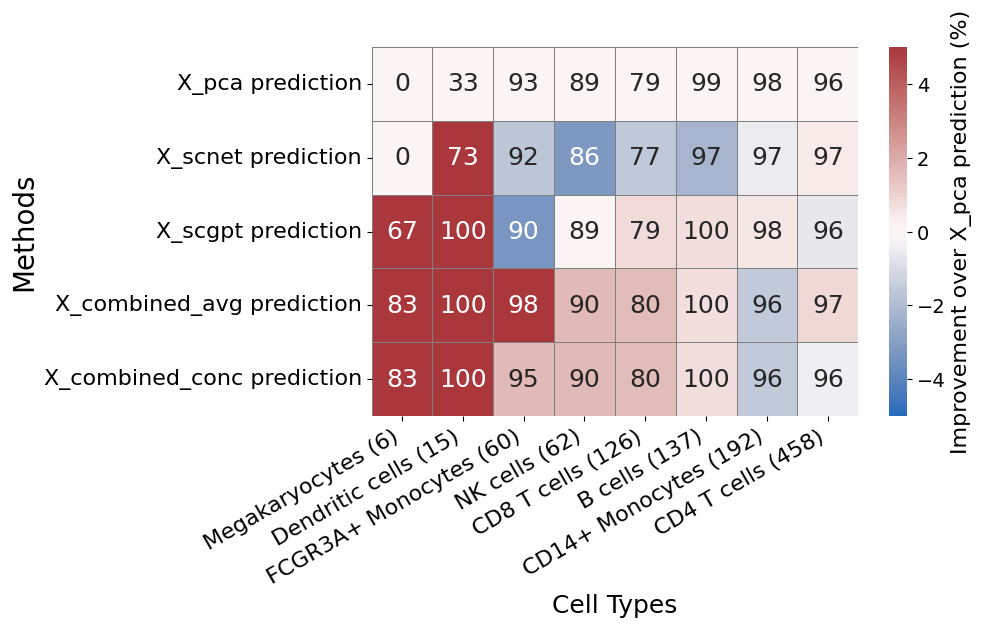

In [96]:
pred_obj = obj.copy()

predictions = [
    'X_pca prediction', 
    'X_scnet prediction', 
    'X_scgpt prediction', 
    'X_combined_avg prediction', 
    'X_combined_conc prediction'
]

make_method_celltype_heatmap_improvement(pred_obj, predictions, baseline_method="X_pca prediction")